In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Dataset

df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Basic Information

print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nFirst Five Rows:\n")
display(df.head())

Dataset Shape: (235795, 56)

Column Names:

['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

First Five Rows:



,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:
# Dataset Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [5]:
# Statistical Summary

display(df.describe())

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [6]:
# Missing Values

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing.sort_values(ascending=False))

No missing values found.


In [7]:
# Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
# Target Variable Distribution

print(df["label"].value_counts())

print("\nPercentage Distribution\n")

print(df["label"].value_counts(normalize=True) * 100)

label
1    134850
0    100945
Name: count, dtype: int64

Percentage Distribution

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


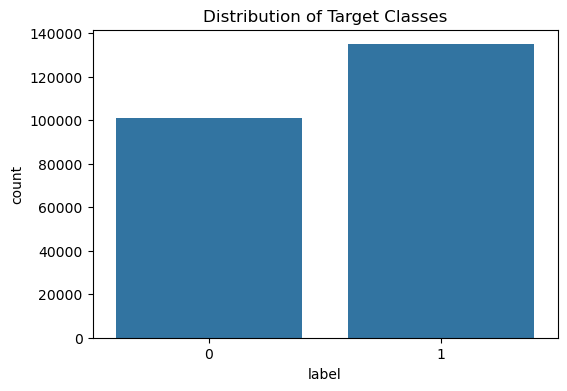

In [9]:
# Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=df
)

plt.title("Distribution of Target Classes")

plt.show()

In [10]:
# Drop Unnecessary Text Columns

columns_to_drop = [
    "FILENAME",
    "URL",
    "Domain",
    "TLD",
    "Title"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)
display(df.head())

print(df.columns.tolist())

(235795, 51)


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,1,10,2,7,42,2,5,1
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,1,1,1,3,27,15,22,1,31,1
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,0,1,244,15,34,72,1,85,1


['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [11]:
# Separate Features and Target

X = df.drop("label", axis=1)
y = df["label"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (235795, 50)
Target Shape : (235795,)


In [12]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (188636, 50)
Testing Samples : (47159, 50)


In [13]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Feature Scaling Completed!
Scaler saved successfully!


Accuracy : 0.9999
Precision: 0.9998
Recall   : 1.0000
F1 Score : 0.9999
AUC Score: 1.0000
MCC Score: 0.9997


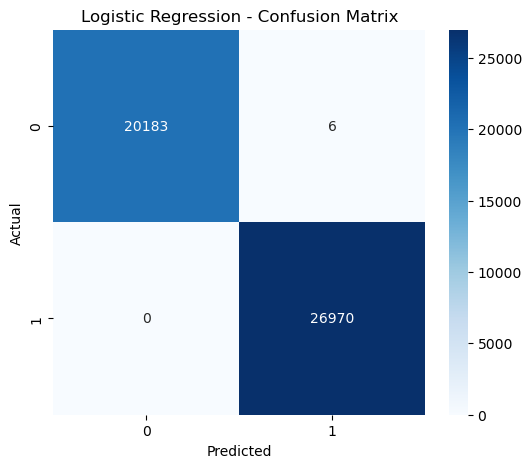

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [14]:
# Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

# Predictions

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression Metrics

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_mcc = matthews_corrcoef(y_test, y_pred_lr)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"AUC Score: {lr_auc:.4f}")
print(f"MCC Score: {lr_mcc:.4f}")

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report

print(classification_report(y_test, y_pred_lr))



In [26]:
# Save Logistic Regression Model

joblib.dump(logistic_model, "logistic_regression.pkl")

['logistic_regression.pkl']

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC Score: 1.0000
MCC Score: 1.0000


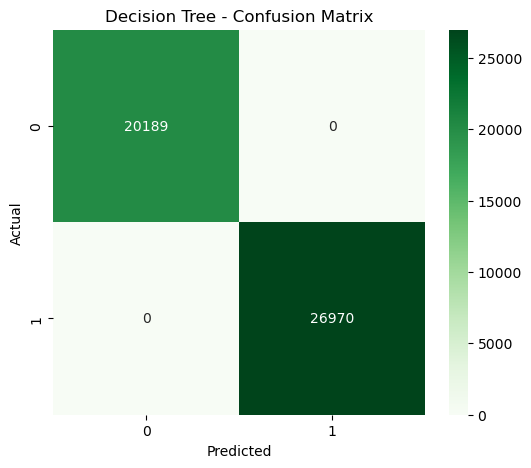

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



['decision_tree.pkl']

In [16]:
# Train Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Decision Tree Predictions

y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

# Decision Tree Metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)
dt_mcc = matthews_corrcoef(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"AUC Score: {dt_auc:.4f}")
print(f"MCC Score: {dt_mcc:.4f}")

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred_dt))

joblib.dump(decision_tree, "decision_tree.pkl")

Accuracy : 0.9986
Precision: 0.9980
Recall   : 0.9994
F1 Score : 0.9987
AUC Score: 0.9995
MCC Score: 0.9971


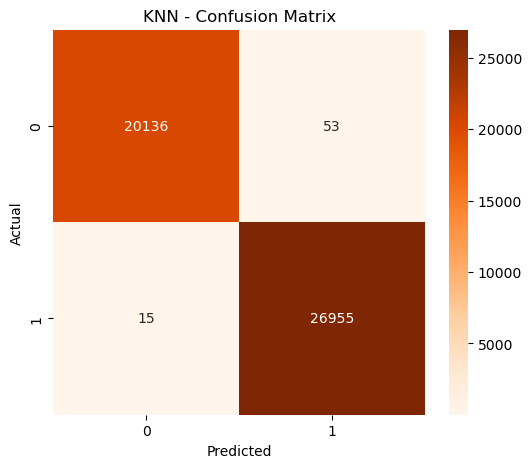

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



['knn.pkl']

In [17]:
# Train KNN

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

# KNN Predictions

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# KNN Metrics

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)
knn_mcc = matthews_corrcoef(y_test, y_pred_knn)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")
print(f"AUC Score: {knn_auc:.4f}")
print(f"MCC Score: {knn_mcc:.4f}")

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred_knn))

joblib.dump(knn_model, "knn.pkl")

Accuracy : 0.9853
Precision: 0.9997
Recall   : 0.9745
F1 Score : 0.9870
AUC Score: 0.9998
MCC Score: 0.9705


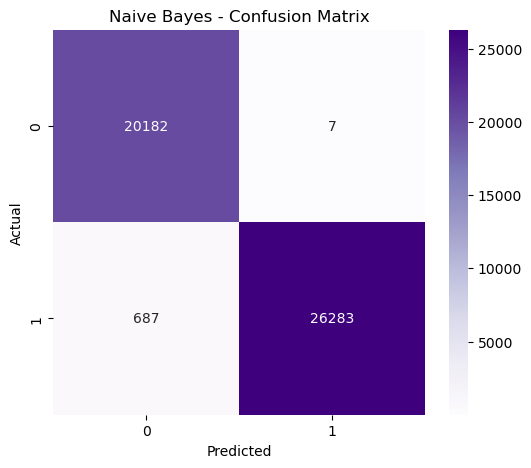

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     20189
           1       1.00      0.97      0.99     26970

    accuracy                           0.99     47159
   macro avg       0.98      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



['naive_bayes.pkl']

In [18]:
# Train Gaussian Naive Bayes

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

# Naive Bayes Predictions

y_pred_nb = naive_bayes.predict(X_test)
y_prob_nb = naive_bayes.predict_proba(X_test)[:, 1]

# Naive Bayes Metrics

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_prob_nb)
nb_mcc = matthews_corrcoef(y_test, y_pred_nb)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")
print(f"AUC Score: {nb_auc:.4f}")
print(f"MCC Score: {nb_mcc:.4f}")

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred_nb))

joblib.dump(naive_bayes, "naive_bayes.pkl")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC Score: 1.0000
MCC Score: 1.0000


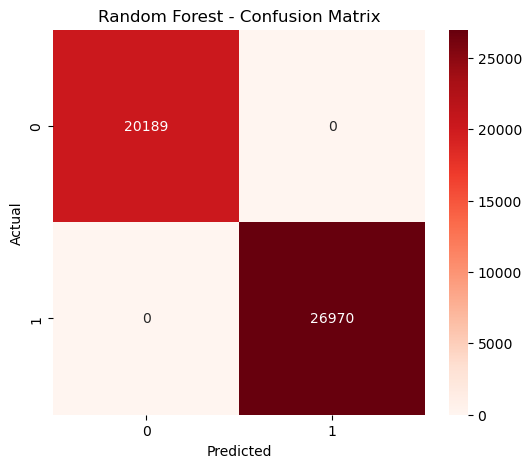

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



['random_forest.pkl']

In [19]:
# Train Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Random Forest Predictions

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Random Forest Metrics

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_mcc = matthews_corrcoef(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"AUC Score: {rf_auc:.4f}")
print(f"MCC Score: {rf_mcc:.4f}")

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred_rf))

joblib.dump(random_forest, "random_forest.pkl")


In [20]:
# Store Model Results

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "AUC": lr_auc,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1,
    "MCC": lr_mcc
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "AUC": dt_auc,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "MCC": dt_mcc
})

results.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "AUC": knn_auc,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1 Score": knn_f1,
    "MCC": knn_mcc
})

results.append({
    "Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "AUC": nb_auc,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1,
    "MCC": nb_mcc
})

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "AUC": rf_auc,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "MCC": rf_mcc
})

In [21]:
# Model Comparison Table

results_df = pd.DataFrame(results)

# Round values for better presentation
results_df = results_df.round(4)

display(results_df)

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9999,1.0000,0.9998,1.0000,0.9999,0.9997
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN,0.9986,0.9995,0.9980,0.9994,0.9987,0.9971
3,Naive Bayes,0.9853,0.9998,0.9997,0.9745,0.9870,0.9705
4,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [22]:
# Save comparison table
results_df.to_csv("model_comparison_results.csv", index=False)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


In [27]:
# Save only the test dataset

test_df = X_test.copy()

test_df["label"] = y_test.values

test_df.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully!")

print(test_df.shape)
test_df.head()

test_data.csv created successfully!
(47159, 51)


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
173310,25,18,0,100.0,1.000000,0.522907,0.063855,3,1,0,...,0,0,1,16,12,29,65,0,11,1
62486,25,18,0,100.0,0.727273,0.003322,0.048722,2,2,0,...,0,0,0,62,6,8,121,0,127,1
14858,24,17,0,100.0,1.000000,0.522907,0.063283,3,1,0,...,0,0,1,9,7,12,6,0,6,1
82943,32,25,0,100.0,1.000000,0.522907,0.056111,3,1,0,...,1,0,1,64,5,5,1582,2,1590,1
72539,23,16,0,100.0,1.000000,0.522907,0.050065,3,1,0,...,1,0,1,35,3,22,103,0,9,1


In [24]:
%%writefile ML_Assignment2/app.py

print("Hello Streamlit!")

Overwriting ML_Assignment2/app.py


In [25]:
import os

for root, dirs, files in os.walk("ML_Assignment2"):
    print(root)
    for file in files:
        print("   ", file)

ML_Assignment2
    app.py
    ML_Assignment2_Model_Training.ipynb
    model_comparison_results.csv
    test_data.csv
ML_Assignment2\.ipynb_checkpoints
    app-checkpoint.py
ML_Assignment2\dataset
    PhiUSIIL_Phishing_URL_Dataset.csv
ML_Assignment2\models
    decision_tree.pkl
    knn.pkl
    logistic_regression.pkl
    naive_bayes.pkl
    random_forest.pkl
    scaler.pkl
